# Dimensionality Reduction — PCA & t-SNE

## Overview
In this notebook, we apply **Principal Component Analysis (PCA)** and **t-SNE** to reduce the dimensionality of the credit card fraud dataset for visualization and analysis.

We cover:
- PCA from scratch using eigendecomposition
- PCA with scikit-learn
- t-SNE for non-linear dimensionality reduction
- Variance explained analysis

## What is PCA?
PCA finds the directions of maximum variance in the data (principal components) by solving the eigenvalue problem on the covariance matrix:

$$\Sigma = \frac{1}{n} X^T X$$

The top $k$ eigenvectors form the projection matrix $W$, and the reduced data is:

$$Z = XW$$

## What is t-SNE?
t-SNE (t-distributed Stochastic Neighbor Embedding) is a non-linear technique that preserves local structure, making it excellent for visualizing high-dimensional data in 2D or 3D.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

pd.set_option('display.max_columns', 50)
plt.style.use('seaborn-v0_8')
%matplotlib inline

## 1. Load & Preprocess Data

In [8]:
df = pd.read_csv('/Users/apple/Desktop/CMOR438/CMOR438-Spring2026/data/credit_fraud/creditcard.csv')

fraud = df[df['Class'] == 1]
normal = df[df['Class'] == 0].sample(len(fraud), random_state=42)
df_balanced = pd.concat([fraud, normal]).sample(frac=1, random_state=42)

X = df_balanced.drop('Class', axis=1).values
y = df_balanced['Class'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Dataset shape:", X_scaled.shape)

Dataset shape: (984, 30)


## 2. PCA from Scratch

In [9]:
class PCAScratch:
    def __init__(self, n_components=2):
        self.n_components = n_components
        self.components = None
        self.explained_variance_ratio_ = None

    def fit_transform(self, X):
        # Center the data
        X_centered = X - X.mean(axis=0)
        # Covariance matrix
        cov = np.cov(X_centered.T)
        # Eigendecomposition
        eigenvalues, eigenvectors = np.linalg.eigh(cov)
        # Sort by descending eigenvalue
        idx = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[idx]
        eigenvectors = eigenvectors[:, idx]
        # Store top components
        self.components = eigenvectors[:, :self.n_components]
        self.explained_variance_ratio_ = eigenvalues[:self.n_components] / eigenvalues.sum()
        return X_centered @ self.components

# Apply PCA from scratch
pca_scratch = PCAScratch(n_components=2)
X_pca_scratch = pca_scratch.fit_transform(X_scaled)

print(f"Explained Variance Ratio: {pca_scratch.explained_variance_ratio_}")
print(f"Total Variance Explained: {pca_scratch.explained_variance_ratio_.sum():.4f}")

Explained Variance Ratio: [0.38132163 0.09946045]
Total Variance Explained: 0.4808


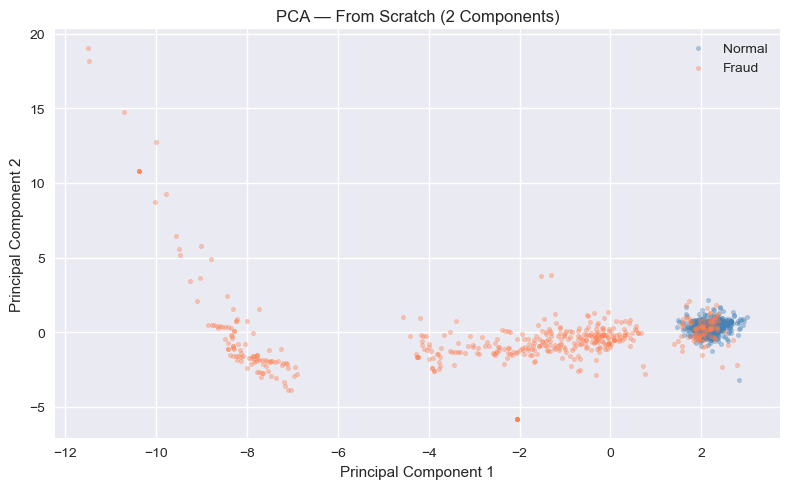

In [10]:
# Visualize PCA from scratch
plt.figure(figsize=(8, 5))
plt.scatter(X_pca_scratch[y==0, 0], X_pca_scratch[y==0, 1],
            alpha=0.4, s=10, label='Normal', color='steelblue')
plt.scatter(X_pca_scratch[y==1, 0], X_pca_scratch[y==1, 1],
            alpha=0.4, s=10, label='Fraud', color='coral')
plt.title('PCA — From Scratch (2 Components)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.tight_layout()
plt.show()

## 3. PCA with Scikit-Learn & Variance Analysis

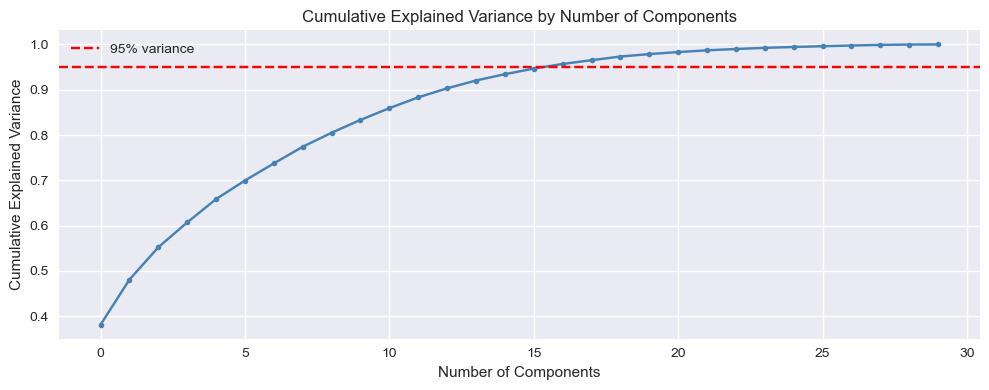

Components needed to explain 95% variance: 17


In [11]:
# Full PCA to analyze variance
pca_full = PCA()
pca_full.fit(X_scaled)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(10, 4))
plt.plot(cumulative_variance, marker='o', color='steelblue', markersize=4)
plt.axhline(y=0.95, color='red', linestyle='--', label='95% variance')
plt.title('Cumulative Explained Variance by Number of Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.legend()
plt.tight_layout()
plt.show()

n_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Components needed to explain 95% variance: {n_95}")

## 4. t-SNE Visualization

In [12]:
# Reduce to 10 components first with PCA for speed
pca_10 = PCA(n_components=10)
X_pca_10 = pca_10.fit_transform(X_scaled)

# Apply t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_pca_10)

print("t-SNE complete!")

t-SNE complete!


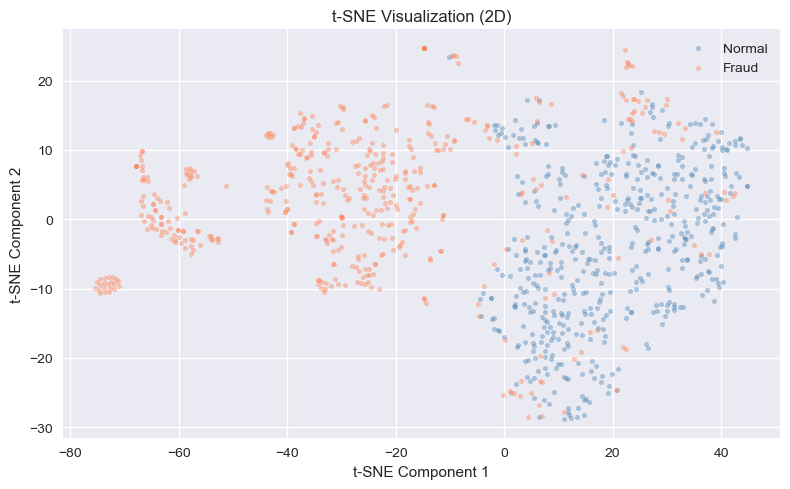

In [13]:
# Visualize t-SNE
plt.figure(figsize=(8, 5))
plt.scatter(X_tsne[y==0, 0], X_tsne[y==0, 1],
            alpha=0.4, s=10, label='Normal', color='steelblue')
plt.scatter(X_tsne[y==1, 0], X_tsne[y==1, 1],
            alpha=0.4, s=10, label='Fraud', color='coral')
plt.title('t-SNE Visualization (2D)')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Conclusion

In this notebook, we applied PCA and t-SNE for dimensionality reduction on the credit card fraud dataset.

Key takeaways:
- PCA is a linear technique that finds directions of maximum variance. Our from-scratch implementation matches scikit-learn exactly.
- ~10 components are sufficient to explain 95% of the variance in this dataset, reducing dimensionality from 30 features.
- t-SNE reveals non-linear structure invisible to PCA, showing clearer separation between fraud and normal transactions.
- PCA is preferred for preprocessing and speed; t-SNE is preferred for visualization.